# DELPHIN — Semana 2: Procesamiento de Audio (DAIC-WOZ)

**Objetivo de la semana:** extraer características acústicas del corpus DAIC-WOZ y dejar preparados los artefactos (`audio_features.csv`, `audio_dataset.csv`, `X_*`, `y_*`, modelo baseline, scaler y métricas) que consumirán las Semanas 3, 4 y 5.

**Corrección metodológica aplicada respecto a la versión anterior:**
- El dataset oficial DAIC-WOZ define 4 archivos: `train_split_Depression_AVEC2017.csv` (107 participantes, con etiquetas), `dev_split_Depression_AVEC2017.csv` (35 participantes, con etiquetas), `test_split_Depression_AVEC2017.csv` (sin etiquetas, solo `Participant_ID`/`Gender`) y `full_test_split.csv` (con etiquetas, reservado exclusivamente para una evaluación final independiente).
- **Entrenamiento → únicamente TRAIN.** **Validación → únicamente DEV.** El TEST oficial y el FULL_TEST **no** se usan para entrenar ni para validar, y no se mezclan con DEV en ningún punto del pipeline.
- Se conserva una columna `split` (`train` / `dev`) en `audio_dataset.csv` para que las semanas siguientes puedan reconstruir la partición oficial sin necesidad de un `train_test_split` aleatorio adicional.


## 1. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Rutas del proyecto y librerías

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import joblib

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Carpeta con los datos crudos del corpus DAIC-WOZ (audios + splits oficiales)
BASE = "/content/drive/MyDrive/DAIC-WOZ"

# Carpeta donde se guardan los productos del proyecto DELPHIN (consumidos por Semanas 3-5)
BASE_PROYECTO = Path("/content/drive/MyDrive/Colab Notebooks/Programa Delphin")
BASE_PROYECTO.mkdir(parents=True, exist_ok=True)

print("Existe BASE:", os.path.exists(BASE))
print("Archivos en BASE:", len(os.listdir(BASE)))
print("Productos se guardarán en:", BASE_PROYECTO)

Existe BASE: True
Archivos en BASE: 1724
Productos se guardarán en: /content/drive/MyDrive/Colab Notebooks/Programa Delphin


## 3. Carga de los splits oficiales y validación de la metodología

Se cargan los cuatro archivos oficiales del protocolo AVEC2017/DAIC-WOZ. `TEST` no tiene etiquetas de depresión y **nunca** se usa para entrenar. `FULL_TEST` sí tiene etiquetas pero se reserva únicamente para una evaluación final independiente si en algún momento se necesita: **no participa del entrenamiento ni de la validación de la Semana 2.**

In [ ]:
train_df = pd.read_csv(f"{BASE}/train_split_Depression_AVEC2017.csv")
dev_df   = pd.read_csv(f"{BASE}/dev_split_Depression_AVEC2017.csv")
test_df  = pd.read_csv(f"{BASE}/test_split_Depression_AVEC2017.csv")
full_test_df = pd.read_csv(f"{BASE}/full_test_split.csv")

print("TRAIN:", train_df.shape, "columnas:", train_df.columns.tolist())
print("DEV  :", dev_df.shape, "columnas:", dev_df.columns.tolist())
print("TEST (sin etiquetas):", test_df.shape, "columnas:", test_df.columns.tolist())
print("FULL_TEST (reservado, no se usa en Semana 2):", full_test_df.shape, "columnas:", full_test_df.columns.tolist())

# Homologar nombres de columnas de etiqueta en full_test (por si se usa en una evaluación final futura)
full_test_df = full_test_df.rename(columns={"PHQ_Binary": "PHQ8_Binary", "PHQ_Score": "PHQ8_Score"})

# Verificación de que no hay solapamiento de participantes entre TRAIN y DEV
solapamiento = set(train_df["Participant_ID"]) & set(dev_df["Participant_ID"])
assert len(solapamiento) == 0, f"TRAIN y DEV comparten participantes: {solapamiento}"
print("\nOK: TRAIN y DEV no comparten participantes.")

TRAIN: (107, 12) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
DEV  : (35, 12) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
TEST (sin etiquetas): (47, 2) columnas: ['participant_ID', 'Gender']
FULL_TEST (reservado, no se usa en Semana 2): (47, 4) columnas: ['Participant_ID', 'PHQ_Binary', 'PHQ_Score', 'Gender']

OK: TRAIN y DEV no comparten participantes.


## 4. Exploración de un audio de ejemplo (participante 300)

Bloque exploratorio/pedagógico: carga a 16 kHz, forma de onda, espectrograma y las familias de características que luego calculará `extract_features`. No forma parte del pipeline de producción.

In [ ]:
AUDIO_DEMO = f"{BASE}/300_AUDIO.wav"

y_demo, sr_demo = librosa.load(AUDIO_DEMO, sr=16000, mono=True)
duracion = librosa.get_duration(y=y_demo, sr=sr_demo)

print("Frecuencia de muestreo:", sr_demo)
print("Muestras:", len(y_demo))
print(f"Duración: {duracion:.2f} segundos")

Frecuencia de muestreo: 16000
Muestras: 10376000
Duración: 648.50 segundos


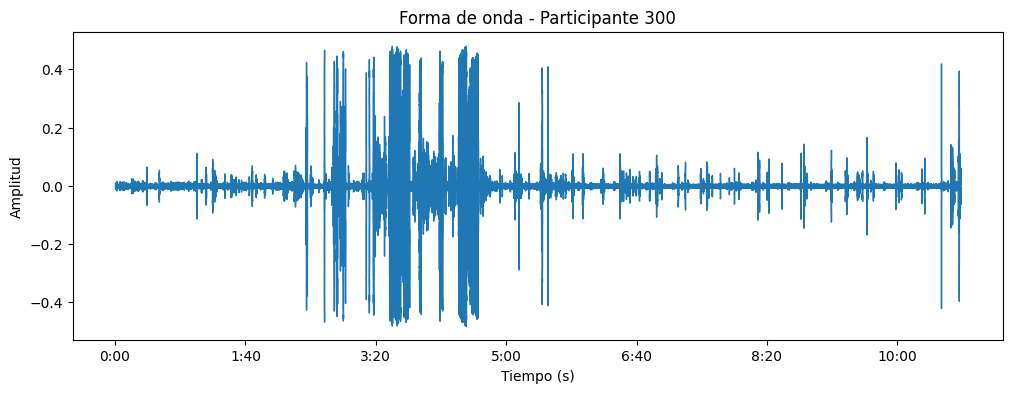

In [ ]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_demo, sr=sr_demo)
plt.title("Forma de onda - Participante 300")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

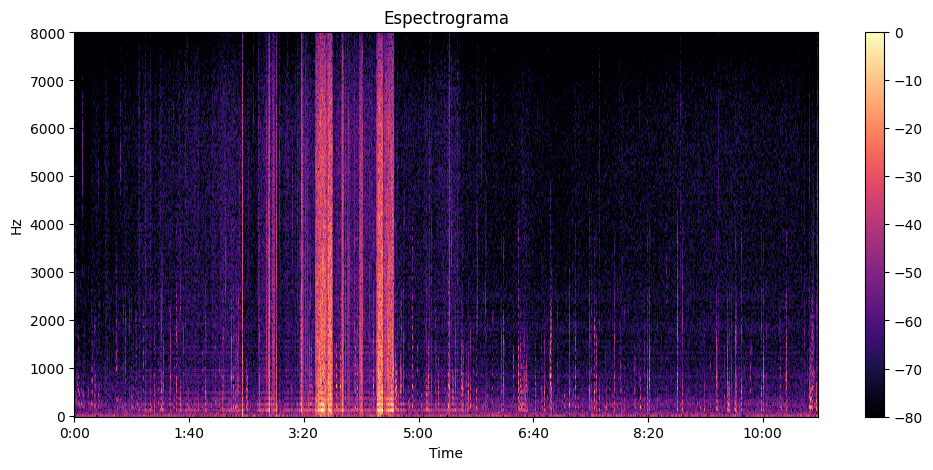

In [ ]:
D = librosa.amplitude_to_db(
    np.abs(librosa.stft(y_demo, n_fft=512, hop_length=256)),
    ref=np.max
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(D, sr=sr_demo, hop_length=256, x_axis="time", y_axis="hz")
plt.colorbar()
plt.title("Espectrograma")
plt.show()

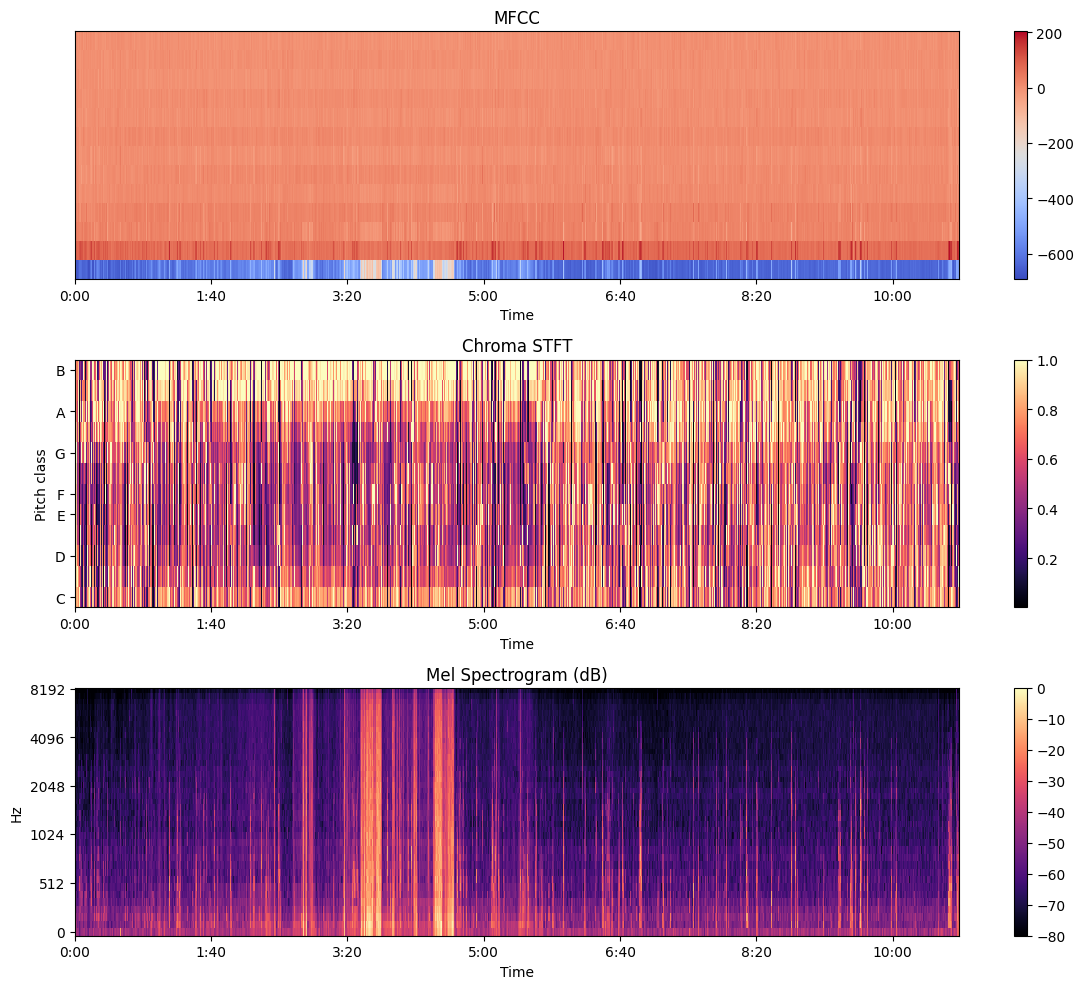

In [ ]:
mfcc_demo = librosa.feature.mfcc(y=y_demo, sr=sr_demo, n_mfcc=13, n_fft=512, hop_length=256)
chroma_demo = librosa.feature.chroma_stft(y=y_demo, sr=sr_demo, n_fft=512, hop_length=256)
mel_demo = librosa.feature.melspectrogram(y=y_demo, sr=sr_demo, n_fft=512, hop_length=256, n_mels=40)
mel_demo_db = librosa.power_to_db(mel_demo, ref=np.max)

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

img0 = librosa.display.specshow(mfcc_demo, sr=sr_demo, hop_length=256, x_axis="time", ax=ax[0])
ax[0].set_title("MFCC")
fig.colorbar(img0, ax=ax[0])

img1 = librosa.display.specshow(chroma_demo, sr=sr_demo, hop_length=256, x_axis="time", y_axis="chroma", ax=ax[1])
ax[1].set_title("Chroma STFT")
fig.colorbar(img1, ax=ax[1])

img2 = librosa.display.specshow(mel_demo_db, sr=sr_demo, hop_length=256, x_axis="time", y_axis="mel", ax=ax[2])
ax[2].set_title("Mel Spectrogram (dB)")
fig.colorbar(img2, ax=ax[2])

plt.tight_layout()
plt.show()

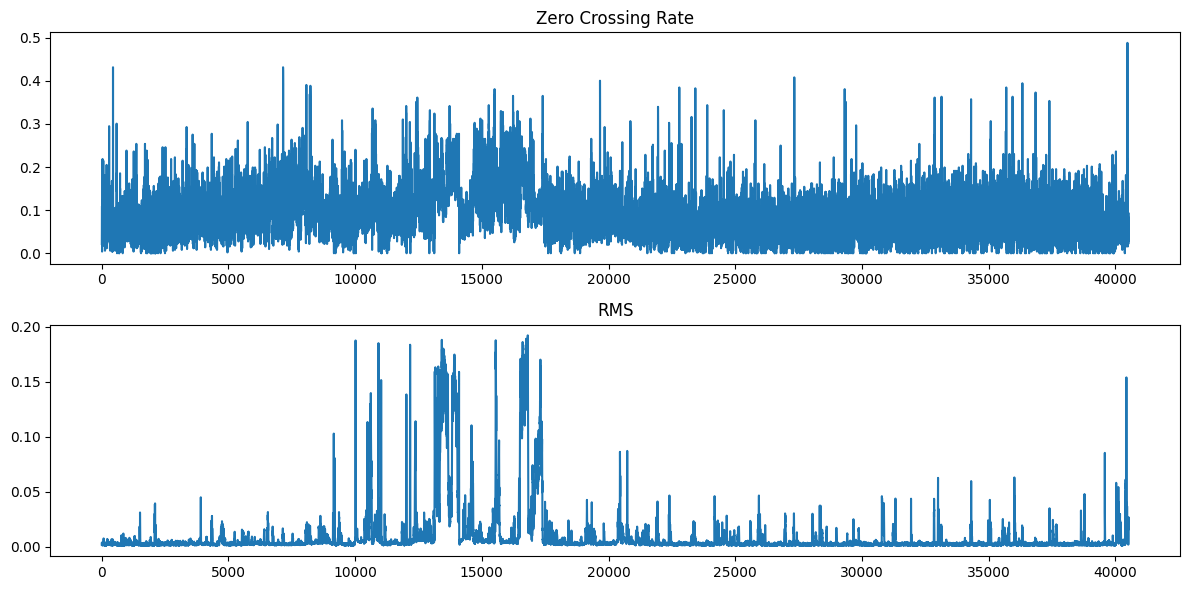

In [ ]:
zcr_demo = librosa.feature.zero_crossing_rate(y_demo, frame_length=512, hop_length=256)
rms_demo = librosa.feature.rms(y=y_demo, frame_length=512, hop_length=256)

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(zcr_demo[0])
ax[0].set_title("Zero Crossing Rate")
ax[1].plot(rms_demo[0])
ax[1].set_title("RMS")
plt.tight_layout()
plt.show()

## 5. Función de extracción de características

Pipeline por archivo de audio: carga a 16 kHz mono → eliminación de silencios → normalización de amplitud → extracción de MFCC, Delta, Delta-Delta, Chroma STFT, Mel Spectrogram (log), Zero Crossing Rate y RMS → agregación estadística (media y desviación estándar por coeficiente/banda).

Respecto a la versión anterior del notebook, esta función **agrega** Delta-Delta, Chroma STFT y Mel Spectrogram (antes ausentes) y **agrega** un paso explícito de normalización de amplitud antes de extraer características.

In [ ]:
N_FFT = 512
HOP_LENGTH = 256
N_MFCC = 13
N_MELS = 40


def extract_features(wav_path, sr_target=16000, top_db=20):
    """Extrae un vector de características acústicas agregadas (media + std)
    a partir de un archivo de audio.

    Etapas: carga a 16 kHz mono -> trim de silencios -> normalización de
    amplitud -> MFCC, Delta, Delta-Delta, Chroma STFT, Mel Spectrogram,
    Zero Crossing Rate y RMS.
    """

    # Carga y conversión a mono + remuestreo a 16 kHz
    y, sr = librosa.load(wav_path, sr=sr_target, mono=True)

    # Eliminación de silencios
    y, _ = librosa.effects.trim(y, top_db=top_db)

    if y.size == 0:
        raise ValueError(f"Audio vacío tras el trim de silencios: {wav_path}")

    # Normalización de amplitud (peak normalization)
    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    # --- Características ---
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)

    blocks = [mfcc, delta, delta2, chroma, mel_db, zcr, rms]

    features = np.concatenate(
        [b.mean(axis=1) for b in blocks] + [b.std(axis=1) for b in blocks]
    )

    return features.astype(np.float32)


def feature_names():
    """Nombres de columnas alineados con el orden producido por extract_features."""
    groups = [
        ("mfcc", N_MFCC),
        ("delta", N_MFCC),
        ("delta2", N_MFCC),
        ("chroma", 12),
        ("mel", N_MELS),
        ("zcr", 1),
        ("rms", 1),
    ]
    names = []
    for stat in ["mean", "std"]:
        for group_name, size in groups:
            names.extend([f"{group_name}_{stat}_{i}" for i in range(size)])
    return names

## 6. Prueba de `extract_features` con el participante 300

In [ ]:
features_demo = extract_features(f"{BASE}/300_AUDIO.wav")
nombres = feature_names()

print("Longitud del vector de características:", features_demo.shape)
assert len(nombres) == features_demo.shape[0], "Los nombres de columnas no coinciden con el vector de features"
print("OK: nombres de columnas alineados con el vector de características.")

Longitud del vector de características: (186,)
OK: nombres de columnas alineados con el vector de características.


## 7. Procesamiento de un conjunto completo de participantes

Función reutilizable que recorre los `Participant_ID` de un split, extrae características para cada audio disponible y reporta explícitamente los participantes cuyo audio no se encontró (en vez de omitirlos silenciosamente).

In [ ]:
def process_split(participant_ids, base_audio_dir, split_name):
    filas = []
    faltantes = []

    for pid in participant_ids:
        archivo = f"{base_audio_dir}/{pid}_AUDIO.wav"

        if not os.path.exists(archivo):
            faltantes.append(pid)
            continue

        feats = extract_features(archivo)
        filas.append([pid] + feats.tolist())

    columnas = ["Participant_ID"] + feature_names()
    df_feats = pd.DataFrame(filas, columns=columnas)
    df_feats["split"] = split_name

    print(f"[{split_name}] participantes solicitados: {len(participant_ids)} | "
          f"procesados: {len(df_feats)} | sin audio: {len(faltantes)}")
    if faltantes:
        print(f"[{split_name}] IDs sin audio: {faltantes}")

    return df_feats

## 8. Procesar TRAIN y DEV (los únicos splits usados en la Semana 2)

In [ ]:
audio_train_df = process_split(train_df["Participant_ID"], BASE, "train")
audio_dev_df = process_split(dev_df["Participant_ID"], BASE, "dev")

audio_features_df = pd.concat([audio_train_df, audio_dev_df], ignore_index=True)

print("\naudio_features_df:", audio_features_df.shape)
audio_features_df.head()

[train] participantes solicitados: 107 | procesados: 107 | sin audio: 0
[dev] participantes solicitados: 35 | procesados: 35 | sin audio: 0

audio_features_df: (142, 188)


,Participant_ID,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,...,mel_std_33,mel_std_34,mel_std_35,mel_std_36,mel_std_37,mel_std_38,mel_std_39,zcr_std_0,rms_std_0,split
0,303,-473.596375,104.109161,11.230720,24.656982,4.632071,-0.546131,-1.616175,4.643320,1.928974,...,5.324068,4.693441,4.462885,4.997854,5.706306,6.426771,6.728725,0.064570,0.027746,train
1,304,-487.871185,95.589272,14.270418,24.362389,9.178817,-3.616383,2.071698,7.770257,3.258178,...,3.933811,3.623964,3.502492,3.403410,3.433353,3.214581,2.484490,0.037200,0.023600,train
2,305,-423.917694,148.635712,22.185574,9.356431,6.876483,-0.207718,-2.218630,-2.179281,-0.039825,...,3.216901,2.577997,2.280060,2.100874,2.142074,1.958771,1.708567,0.022892,0.050635,train
3,310,-623.381042,49.000103,17.258621,19.164902,13.066140,9.516079,5.626300,6.596737,6.134872,...,7.129650,7.508544,7.223728,6.891404,6.083974,4.955707,3.997461,0.065853,0.010255,train
4,312,-590.433960,47.187424,19.283388,16.730452,10.183809,5.688906,3.945691,3.417712,3.928324,...,6.021658,5.940784,5.945962,5.799845,5.485413,4.993739,4.146262,0.072471,0.020781,train


## 9. Construir y guardar `audio_features.csv`

Contiene únicamente TRAIN + DEV, con la columna `split` para poder recuperar la partición oficial en cualquier momento.

In [ ]:
audio_features_df.to_csv(BASE_PROYECTO / "audio_features.csv", index=False)
print("✓ audio_features.csv guardado:", audio_features_df.shape)

✓ audio_features.csv guardado: (142, 188)


## 10. Construir `audio_dataset.csv` (características + etiquetas)

Se agregan las etiquetas `PHQ8_Binary` y `PHQ8_Score` desde `train_split` y `dev_split` respectivamente. El TEST oficial (sin etiquetas) y el FULL_TEST quedan explícitamente excluidos de este merge.

In [ ]:
labels_train = train_df[["Participant_ID", "PHQ8_Binary", "PHQ8_Score"]].copy()
labels_dev = dev_df[["Participant_ID", "PHQ8_Binary", "PHQ8_Score"]].copy()
labels_df = pd.concat([labels_train, labels_dev], ignore_index=True)

audio_dataset_df = audio_features_df.merge(labels_df, on="Participant_ID", how="inner")

# Todo participante procesado debe haber encontrado su etiqueta (TRAIN/DEV siempre las tienen)
assert len(audio_dataset_df) == len(audio_features_df), (
    "Se perdieron participantes al unir características con etiquetas; "
    "revisar Participant_ID no encontrados en TRAIN/DEV."
)

audio_dataset_df.to_csv(BASE_PROYECTO / "audio_dataset.csv", index=False)

print("✓ audio_dataset.csv guardado:", audio_dataset_df.shape)
print(audio_dataset_df["split"].value_counts())
audio_dataset_df.head()

✓ audio_dataset.csv guardado: (142, 190)
split
train    107
dev       35
Name: count, dtype: int64


,Participant_ID,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,...,mel_std_35,mel_std_36,mel_std_37,mel_std_38,mel_std_39,zcr_std_0,rms_std_0,split,PHQ8_Binary,PHQ8_Score
0,303,-473.596375,104.109161,11.230720,24.656982,4.632071,-0.546131,-1.616175,4.643320,1.928974,...,4.462885,4.997854,5.706306,6.426771,6.728725,0.064570,0.027746,train,0,0
1,304,-487.871185,95.589272,14.270418,24.362389,9.178817,-3.616383,2.071698,7.770257,3.258178,...,3.502492,3.403410,3.433353,3.214581,2.484490,0.037200,0.023600,train,0,6
2,305,-423.917694,148.635712,22.185574,9.356431,6.876483,-0.207718,-2.218630,-2.179281,-0.039825,...,2.280060,2.100874,2.142074,1.958771,1.708567,0.022892,0.050635,train,0,7
3,310,-623.381042,49.000103,17.258621,19.164902,13.066140,9.516079,5.626300,6.596737,6.134872,...,7.223728,6.891404,6.083974,4.955707,3.997461,0.065853,0.010255,train,0,4
4,312,-590.433960,47.187424,19.283388,16.730452,10.183809,5.688906,3.945691,3.417712,3.928324,...,5.945962,5.799845,5.485413,4.993739,4.146262,0.072471,0.020781,train,0,2


## 11. Verificación: TEST y FULL_TEST no participan del dataset

In [29]:
print(test_df.columns.tolist())
print(full_test_df.columns.tolist())

['participant_ID', 'Gender']
['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender']


In [30]:
# ============================================================
# Verificación de aislamiento entre TRAIN/DEV y TEST
# ============================================================

# Eliminar espacios en los nombres de columnas
audio_dataset_df.columns = audio_dataset_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()
full_test_df.columns = full_test_df.columns.str.strip()

# Unificar nombres de columnas
test_df = test_df.rename(columns={"participant_ID": "Participant_ID"})
full_test_df = full_test_df.rename(columns={"participant_ID": "Participant_ID"})

# Obtener conjuntos de participantes
ids_dataset = set(audio_dataset_df["Participant_ID"])
ids_test = set(test_df["Participant_ID"])
ids_full_test = set(full_test_df["Participant_ID"])

# Verificar que TEST no esté mezclado con TRAIN/DEV
assert ids_dataset.isdisjoint(ids_test), \
    "❌ Hay participantes de TEST dentro de audio_dataset."

# Intersección informativa con FULL_TEST
interseccion_full_test = ids_dataset & ids_full_test

print("=" * 60)
print("VALIDACIÓN DE PARTICIPANTES")
print("=" * 60)
print(f"Participantes en audio_dataset : {len(ids_dataset)}")
print(f"Participantes en TEST         : {len(ids_test)}")
print(f"Participantes en FULL_TEST    : {len(ids_full_test)}")
print()

print("Participantes de TEST dentro del dataset:",
      len(ids_dataset & ids_test))

print("Participantes que además aparecen en FULL_TEST:",
      len(interseccion_full_test))

if len(interseccion_full_test) > 0:
    print("\nIDs compartidos con FULL_TEST:")
    print(sorted(interseccion_full_test))

print("\n✅ OK: la metodología TRAIN/DEV está aislada de TEST.")
print("✅ Validación final completada.")

VALIDACIÓN DE PARTICIPANTES
Participantes en audio_dataset : 142
Participantes en TEST         : 47
Participantes en FULL_TEST    : 47

Participantes de TEST dentro del dataset: 0
Participantes que además aparecen en FULL_TEST: 0

✅ OK: la metodología TRAIN/DEV está aislada de TEST.
✅ Validación final completada.


## 12. Construcción de `X`/`y` usando el split oficial

A diferencia de la versión anterior (que hacía un `train_test_split` aleatorio 80/20 sobre DEV+FULL_TEST), aquí se usa directamente la partición oficial del corpus: **TRAIN para entrenar, DEV para validar.**

In [31]:
print("=" * 60)
print("RESUMEN FINAL DEL DATASET DE AUDIO")
print("=" * 60)
print(f"Total de participantes: {len(audio_dataset_df)}")
print(f"Controles (0): {(audio_dataset_df['PHQ8_Binary']==0).sum()}")
print(f"Depresión (1): {(audio_dataset_df['PHQ8_Binary']==1).sum()}")
print("\nDistribución porcentual:")
print(audio_dataset_df['PHQ8_Binary'].value_counts(normalize=True)*100)

RESUMEN FINAL DEL DATASET DE AUDIO
Total de participantes: 142
Controles (0): 100
Depresión (1): 42

Distribución porcentual:
PHQ8_Binary
0    70.422535
1    29.577465
Name: proportion, dtype: float64


## 13. Construcción de `X`/`y` usando el split oficial

A diferencia de la versión anterior (que hacía un `train_test_split` aleatorio 80/20 sobre DEV+FULL_TEST), aquí se usa directamente la partición oficial del corpus: **TRAIN para entrenar, DEV para validar.**

In [32]:
feature_cols = feature_names()

train_mask = audio_dataset_df["split"] == "train"
dev_mask = audio_dataset_df["split"] == "dev"

X_train_raw = audio_dataset_df.loc[train_mask, feature_cols].values
y_train = audio_dataset_df.loc[train_mask, "PHQ8_Binary"].values.astype(np.float32)

X_dev_raw = audio_dataset_df.loc[dev_mask, feature_cols].values
y_dev = audio_dataset_df.loc[dev_mask, "PHQ8_Binary"].values.astype(np.float32)

print("X_train:", X_train_raw.shape, " y_train:", y_train.shape)
print("X_dev  :", X_dev_raw.shape, " y_dev  :", y_dev.shape)

X_train: (107, 186)  y_train: (107,)
X_dev  : (35, 186)  y_dev  : (35,)


## 14. Escalado de características

`StandardScaler` ajustado **únicamente con TRAIN** y luego aplicado a TRAIN y a DEV, para evitar fuga de información (data leakage) desde el conjunto de validación.

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_dev = scaler.transform(X_dev_raw)

joblib.dump(scaler, BASE_PROYECTO / "audio_scaler.pkl")
print("✓ Scaler ajustado sobre TRAIN y guardado en audio_scaler.pkl")

✓ Scaler ajustado sobre TRAIN y guardado en audio_scaler.pkl


## 15. Conversión a tensores de PyTorch

In [34]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_dev_t = torch.tensor(X_dev, dtype=torch.float32)
y_dev_t = torch.tensor(y_dev, dtype=torch.float32).view(-1, 1)

print(X_train_t.shape, y_train_t.shape)
print(X_dev_t.shape, y_dev_t.shape)

torch.Size([107, 186]) torch.Size([107, 1])
torch.Size([35, 186]) torch.Size([35, 1])


## 16. Dataset y DataLoader (`train_loader`, `valid_loader`)

In [35]:
train_dataset = TensorDataset(X_train_t, y_train_t)
valid_dataset = TensorDataset(X_dev_t, y_dev_t)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

print("Batches de entrenamiento:", len(train_loader))
print("Batches de validación   :", len(valid_loader))

Batches de entrenamiento: 14
Batches de validación   : 5


## 17. Arquitectura del modelo

**Nota metodológica:** el notebook original nombraba a esta red "CNN-1D", pero el código implementado (`AudioMLP`) es en realidad un perceptrón multicapa (`nn.Linear`), sin ninguna capa `nn.Conv1d`. Se conserva como MLP porque es la arquitectura correcta para este tipo de entrada: `extract_features` produce un **vector agregado** (media/std por coeficiente), es decir, ya no existe una dimensión temporal sobre la que una convolución 1D tenga algo que recorrer. Una CNN-1D genuina requeriría alimentar secuencias (por ejemplo los MFCC por frame, sin agregar) en lugar del vector estadístico actual. Si en una semana futura se desea explorar una CNN-1D real sobre secuencias de frames, es un cambio de representación de entrada, no solo de arquitectura, y conviene tratarlo como una variante explícita más adelante en vez de forzarlo aquí.

Único ajuste funcional: la dimensión de entrada ya no está hardcodeada en 56; se toma dinámicamente de `X_train.shape[1]` porque el vector de características ahora incluye Delta-Delta, Chroma y Mel.

In [36]:
class AudioMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_t.shape[1]
model = AudioMLP(input_dim)
print(model)

x_test = torch.randn(4, input_dim)
y_hat = model(x_test)
print("Forma de salida de prueba:", y_hat.shape)

AudioMLP(
  (net): Sequential(
    (0): Linear(in_features=186, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Forma de salida de prueba: torch.Size([4, 1])


## 18. Entrenamiento con validación en cada época

Entrena únicamente sobre `train_loader` y valida sobre `valid_loader` (DEV) al final de cada época. Se guarda el mejor modelo según F1 de validación (checkpointing), en vez de quedarse solo con el modelo de la última época.

In [37]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

N_EPOCHS = 50
best_val_f1 = -1.0
best_state = None

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(N_EPOCHS):
    # --- entrenamiento ---
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # --- validación ---
    model.eval()
    val_running_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_running_loss += loss.item()

            preds = (outputs > 0.5).float()
            all_preds.append(preds)
            all_targets.append(y_batch)

    val_loss = val_running_loss / len(valid_loader)
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

# Cargar el mejor modelo encontrado durante el entrenamiento (según F1 en DEV)
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nMejor F1 de validación: {best_val_f1:.4f} (modelo restaurado)")

Epoch 01 | train_loss=0.6748 | val_loss=0.6036 | val_acc=0.6571 | val_f1=0.0000
Epoch 02 | train_loss=0.5768 | val_loss=0.5783 | val_acc=0.6571 | val_f1=0.0000
Epoch 03 | train_loss=0.5613 | val_loss=0.5790 | val_acc=0.6571 | val_f1=0.0000
Epoch 04 | train_loss=0.5248 | val_loss=0.5779 | val_acc=0.6857 | val_f1=0.2667
Epoch 05 | train_loss=0.5353 | val_loss=0.6052 | val_acc=0.6286 | val_f1=0.2353
Epoch 06 | train_loss=0.4715 | val_loss=0.6439 | val_acc=0.6286 | val_f1=0.2353
Epoch 07 | train_loss=0.4759 | val_loss=0.7040 | val_acc=0.6000 | val_f1=0.2222
Epoch 08 | train_loss=0.3768 | val_loss=0.7629 | val_acc=0.6000 | val_f1=0.2222
Epoch 09 | train_loss=0.3902 | val_loss=0.8382 | val_acc=0.6000 | val_f1=0.2222
Epoch 10 | train_loss=0.3646 | val_loss=0.8996 | val_acc=0.6000 | val_f1=0.2222
Epoch 11 | train_loss=0.3391 | val_loss=1.0236 | val_acc=0.6000 | val_f1=0.2222
Epoch 12 | train_loss=0.3419 | val_loss=1.1261 | val_acc=0.5714 | val_f1=0.2105
Epoch 13 | train_loss=0.2996 | val_loss=

## 19. Curvas de entrenamiento y validación

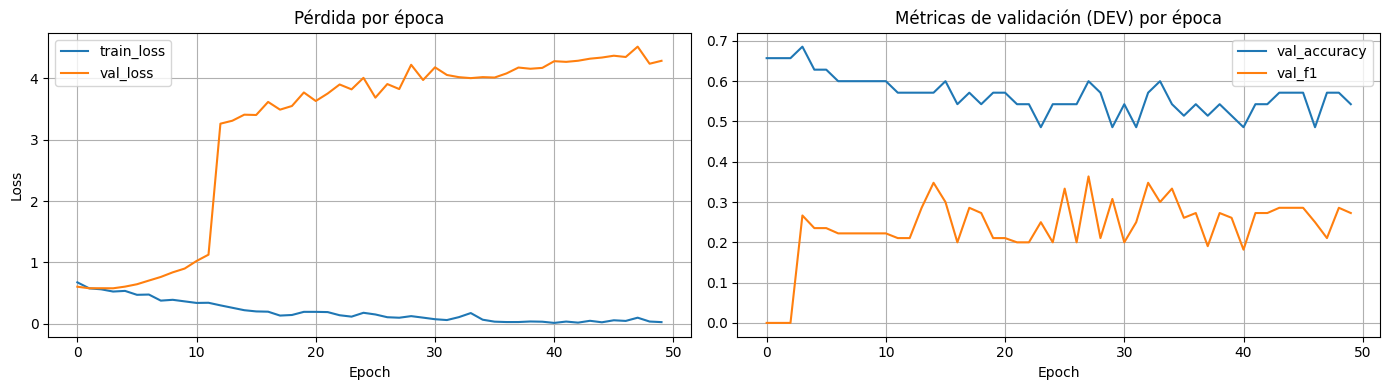

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(history["train_loss"], label="train_loss")
ax[0].plot(history["val_loss"], label="val_loss")
ax[0].set_title("Pérdida por época")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history["val_acc"], label="val_accuracy")
ax[1].plot(history["val_f1"], label="val_f1")
ax[1].set_title("Métricas de validación (DEV) por época")
ax[1].set_xlabel("Epoch")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 20. Evaluación final del mejor modelo sobre DEV

In [39]:
model.eval()
with torch.no_grad():
    y_pred_dev = model(X_dev_t)
    y_pred_dev = (y_pred_dev > 0.5).float()

acc = accuracy_score(y_dev_t, y_pred_dev)
f1 = f1_score(y_dev_t, y_pred_dev, zero_division=0)
cm = confusion_matrix(y_dev_t, y_pred_dev)

print("Accuracy (DEV):", acc)
print("F1 (DEV)      :", f1)
print("\nMatriz de confusión (DEV):")
print(cm)
print("\nReporte de clasificación (DEV):")
print(classification_report(y_dev_t, y_pred_dev, zero_division=0))

Accuracy (DEV): 0.6
F1 (DEV)      : 0.36363636363636365

Matriz de confusión (DEV):
[[17  6]
 [ 8  4]]

Reporte de clasificación (DEV):
              precision    recall  f1-score   support

         0.0       0.68      0.74      0.71        23
         1.0       0.40      0.33      0.36        12

    accuracy                           0.60        35
   macro avg       0.54      0.54      0.54        35
weighted avg       0.58      0.60      0.59        35



## 21. Guardar productos de la Semana 2

Todo lo que consumen las Semanas 3, 4 y 5 queda en `BASE_PROYECTO`:
- `audio_features.csv`, `audio_dataset.csv` (ya guardados, con columna `split`)
- `X_audio.npy` / `y_audio.npy`: TRAIN+DEV concatenados (en ese orden) junto con `split_audio.npy` para poder filtrar por partición oficial
- `X_train_audio.npy` / `y_train_audio.npy` y `X_dev_audio.npy` / `y_dev_audio.npy`: partición oficial ya separada, lista para usar directamente
- `audio_scaler.pkl`: el `StandardScaler` ajustado en TRAIN (debe reutilizarse, no reajustarse, en semanas posteriores)
- `audio_mlp_best.pth`: pesos del mejor modelo (según F1 en DEV)
- `audio_week2_metrics.json`: métricas finales e historial de entrenamiento

In [40]:
import json as _json

# --- matrices combinadas (orden: TRAIN seguido de DEV) ---
X_audio = np.concatenate([X_train, X_dev], axis=0)
y_audio = np.concatenate([y_train, y_dev], axis=0)
split_audio = np.array(["train"] * len(y_train) + ["dev"] * len(y_dev))

np.save(BASE_PROYECTO / "X_audio.npy", X_audio)
np.save(BASE_PROYECTO / "y_audio.npy", y_audio)
np.save(BASE_PROYECTO / "split_audio.npy", split_audio)

# --- matrices separadas por partición oficial ---
np.save(BASE_PROYECTO / "X_train_audio.npy", X_train)
np.save(BASE_PROYECTO / "y_train_audio.npy", y_train)
np.save(BASE_PROYECTO / "X_dev_audio.npy", X_dev)
np.save(BASE_PROYECTO / "y_dev_audio.npy", y_dev)

# --- modelo ---
torch.save(model.state_dict(), BASE_PROYECTO / "audio_mlp_best.pth")

# --- métricas e historial ---
metrics = {
    "input_dim": int(input_dim),
    "n_epochs": N_EPOCHS,
    "best_val_f1": float(best_val_f1),
    "final_eval_dev": {
        "accuracy": float(acc),
        "f1": float(f1),
        "confusion_matrix": cm.tolist(),
    },
    "history": history,
    "feature_names": feature_names(),
}

with open(BASE_PROYECTO / "audio_week2_metrics.json", "w", encoding="utf-8") as f:
    _json.dump(metrics, f, indent=2, ensure_ascii=False)

print("✓ Todos los productos de la Semana 2 fueron guardados en:", BASE_PROYECTO)

✓ Todos los productos de la Semana 2 fueron guardados en: /content/drive/MyDrive/Colab Notebooks/Programa Delphin


## 22. Verificación final

Recarga todos los artefactos guardados y confirma: (a) tamaños consistentes entre `audio_features.csv` y `audio_dataset.csv`, (b) que TRAIN y DEV no se solapan, (c) que ningún participante de TEST o FULL_TEST quedó incluido, y (d) la distribución de clases en TRAIN y en DEV.

In [41]:
audio_features_check = pd.read_csv(BASE_PROYECTO / "audio_features.csv")
audio_dataset_check = pd.read_csv(BASE_PROYECTO / "audio_dataset.csv")
X_audio_check = np.load(BASE_PROYECTO / "X_audio.npy")
y_audio_check = np.load(BASE_PROYECTO / "y_audio.npy")
split_audio_check = np.load(BASE_PROYECTO / "split_audio.npy", allow_pickle=True)

print("="*60)
print("VERIFICACIÓN FINAL — SEMANA 2")
print("="*60)

print("audio_features.csv:", audio_features_check.shape)
print("audio_dataset.csv :", audio_dataset_check.shape)
print("X_audio.npy        :", X_audio_check.shape)
print("y_audio.npy         :", y_audio_check.shape)

print("\nParticipantes únicos en audio_dataset:", audio_dataset_check["Participant_ID"].nunique())
print("Distribución de split:")
print(audio_dataset_check["split"].value_counts())

print("\nDistribución de PHQ8_Binary por split:")
print(audio_dataset_check.groupby("split")["PHQ8_Binary"].value_counts())

ids_train = set(audio_dataset_check.loc[audio_dataset_check["split"] == "train", "Participant_ID"])
ids_dev = set(audio_dataset_check.loc[audio_dataset_check["split"] == "dev", "Participant_ID"])
ids_test_off = set(test_df["Participant_ID"])
ids_full_test_off = set(full_test_df["Participant_ID"])

assert ids_train.isdisjoint(ids_dev), "TRAIN y DEV se solapan en el dataset final"
assert (ids_train | ids_dev).isdisjoint(ids_test_off), "El TEST oficial quedó incluido en el dataset final"

print("\nOK: TRAIN y DEV no se solapan.")
print("OK: el conjunto TEST oficial no está incluido en el dataset de entrenamiento/validación.")
print("Participantes también presentes en FULL_TEST (informativo):",
      len((ids_train | ids_dev) & ids_full_test_off))

print("\n" + "="*60)
print("SEMANA 2 LISTA PARA LA SEMANA 3 (procesamiento de texto con BERT)")
print("="*60)

VERIFICACIÓN FINAL — SEMANA 2
audio_features.csv: (142, 188)
audio_dataset.csv : (142, 190)
X_audio.npy        : (142, 186)
y_audio.npy         : (142,)

Participantes únicos en audio_dataset: 142
Distribución de split:
split
train    107
dev       35
Name: count, dtype: int64

Distribución de PHQ8_Binary por split:
split  PHQ8_Binary
dev    0              23
       1              12
train  0              77
       1              30
Name: count, dtype: int64

OK: TRAIN y DEV no se solapan.
OK: el conjunto TEST oficial no está incluido en el dataset de entrenamiento/validación.
Participantes también presentes en FULL_TEST (informativo): 0

SEMANA 2 LISTA PARA LA SEMANA 3 (procesamiento de texto con BERT)


## 23. Verificación de los archivos generados

In [42]:
# ============================================================
# VERIFICACIÓN DE LOS ARCHIVOS GENERADOS
# ============================================================

audio_features_check = pd.read_csv(BASE_PROYECTO / "audio_features.csv")
audio_dataset_check = pd.read_csv(BASE_PROYECTO / "audio_dataset.csv")
X_audio_check = np.load(BASE_PROYECTO / "X_audio.npy")
y_audio_check = np.load(BASE_PROYECTO / "y_audio.npy")
split_audio_check = np.load(BASE_PROYECTO / "split_audio.npy", allow_pickle=True)

print("="*60)
print("VERIFICACIÓN DE LOS ARCHIVOS GENERADOS")
print("="*60)

print("audio_features.csv :", audio_features_check.shape)
print("audio_dataset.csv  :", audio_dataset_check.shape)
print("X_audio.npy        :", X_audio_check.shape)
print("y_audio.npy        :", y_audio_check.shape)
print("split_audio.npy    :", split_audio_check.shape)

VERIFICACIÓN DE LOS ARCHIVOS GENERADOS
audio_features.csv : (142, 188)
audio_dataset.csv  : (142, 190)
X_audio.npy        : (142, 186)
y_audio.npy        : (142,)
split_audio.npy    : (142,)


##24. Verificación de integridad del dataset

In [43]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL DATASET
# ============================================================

print("="*60)
print("VERIFICACIÓN DE INTEGRIDAD DEL DATASET")
print("="*60)

print("Participantes únicos:",
      audio_dataset_check["Participant_ID"].nunique())

print("\nDistribución por split:")
print(audio_dataset_check["split"].value_counts())

print("\nDistribución de PHQ8_Binary por split:")
print(audio_dataset_check.groupby("split")["PHQ8_Binary"].value_counts())

# Verificaciones de consistencia

assert audio_dataset_check["Participant_ID"].is_unique, \
    "Hay participantes duplicados."

assert X_audio_check.shape[0] == len(y_audio_check), \
    "X_audio y y_audio tienen diferente tamaño."

assert X_audio_check.shape[0] == len(audio_dataset_check), \
    "X_audio y audio_dataset no coinciden."

print("\n✓ No existen participantes duplicados.")
print("✓ X_audio y y_audio son consistentes.")
print("✓ X_audio coincide con audio_dataset.")

VERIFICACIÓN DE INTEGRIDAD DEL DATASET
Participantes únicos: 142

Distribución por split:
split
train    107
dev       35
Name: count, dtype: int64

Distribución de PHQ8_Binary por split:
split  PHQ8_Binary
dev    0              23
       1              12
train  0              77
       1              30
Name: count, dtype: int64

✓ No existen participantes duplicados.
✓ X_audio y y_audio son consistentes.
✓ X_audio coincide con audio_dataset.


## 24. Validación metodológica (TRAIN / DEV / TEST)

In [44]:
# ============================================================
# VALIDACIÓN METODOLÓGICA DEL DATASET
# ============================================================

ids_train = set(
    audio_dataset_check.loc[
        audio_dataset_check["split"]=="train",
        "Participant_ID"
    ]
)

ids_dev = set(
    audio_dataset_check.loc[
        audio_dataset_check["split"]=="dev",
        "Participant_ID"
    ]
)

ids_test = set(test_df["Participant_ID"])
ids_full_test = set(full_test_df["Participant_ID"])

assert ids_train.isdisjoint(ids_dev), \
    "TRAIN y DEV contienen participantes repetidos."

assert (ids_train | ids_dev).isdisjoint(ids_test), \
    "El conjunto TEST fue incluido en el entrenamiento."

print("="*60)
print("VALIDACIÓN METODOLÓGICA")
print("="*60)

print(f"Participantes TRAIN : {len(ids_train)}")
print(f"Participantes DEV   : {len(ids_dev)}")
print(f"Participantes TEST  : {len(ids_test)}")

print("\nDistribución TRAIN:")
print(audio_dataset_check.loc[
    audio_dataset_check["split"]=="train",
    "PHQ8_Binary"
].value_counts())

print("\nDistribución DEV:")
print(audio_dataset_check.loc[
    audio_dataset_check["split"]=="dev",
    "PHQ8_Binary"
].value_counts())

print("\nParticipantes también presentes en FULL_TEST:",
      len((ids_train | ids_dev) & ids_full_test))

print("\n✓ TRAIN y DEV no se solapan.")
print("✓ TEST oficial no fue utilizado.")
print("✓ No existe data leakage.")
print("\n" + "="*60)
print("SEMANA 2 FINALIZADA - LISTA PARA LA SEMANA 3")
print("="*60)

VALIDACIÓN METODOLÓGICA
Participantes TRAIN : 107
Participantes DEV   : 35
Participantes TEST  : 47

Distribución TRAIN:
PHQ8_Binary
0    77
1    30
Name: count, dtype: int64

Distribución DEV:
PHQ8_Binary
0    23
1    12
Name: count, dtype: int64

Participantes también presentes en FULL_TEST: 0

✓ TRAIN y DEV no se solapan.
✓ TEST oficial no fue utilizado.
✓ No existe data leakage.

SEMANA 2 FINALIZADA - LISTA PARA LA SEMANA 3
